<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/TALLER__1_PDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD NACIONAL DE COLOMBIA - SEDE MANIZALES
HAMERSON JHOEL PIARPUEZAN PIARPUEZAN
- CC. 1004531735

# Taller 1 - Procesamiento Digital de Imágenes

## Clasificación automática de prendas de vestir mediante Deep Learning

En este proyecto se desarrolló un modelo de clasificación de imágenes capaz de reconocer tres tipos de prendas:
- Camisa
- Buzo
- Pantaloneta

La base de datos fue creada manualmente utilizando imágenes propias y gestionada mediante Roboflow.

#1.1 Justificación de la arquitectura


Se implementó una Red Neuronal Convolucional (CNN) debido a que este tipo de arquitectura es altamente eficiente para tareas de clasificación de imágenes y visión por computador.

Las capas convolucionales permiten extraer automáticamente características importantes de las imágenes, como bordes, formas, colores y texturas presentes en las prendas de vestir. Esto facilita que el modelo pueda diferenciar entre las distintas clases del conjunto de datos.

Además, las capas de pooling reducen la dimensionalidad de las imágenes y disminuyen la cantidad de parámetros del modelo, ayudando a reducir el sobreajuste y mejorando el rendimiento computacional.

Finalmente, las capas densas realizan la clasificación final de las imágenes entre las tres categorías propuestas:

- buzo
- camisa
- pantaloneta

#1.2 Función de pérdida y métricas

Se utilizó la función de pérdida categorical_crossentropy debido a que el problema corresponde a una tarea de clasificación multiclase, donde el modelo debe identificar correctamente una de las tres categorías de prendas de vestir.

El optimizador Adam fue seleccionado por su eficiencia y rápida convergencia durante el proceso de entrenamiento, permitiendo ajustar automáticamente los pesos de la red neuronal para mejorar el aprendizaje.

Como métrica principal se utilizó accuracy, ya que permite medir el porcentaje de predicciones correctas realizadas por el modelo sobre el conjunto de datos, facilitando la evaluación del rendimiento de la red neuronal durante el entrenamiento y la validación.

#1.3 Link de Roboflow
https://universe.roboflow.com/hamersons-j/clasificacion-ipquo

# 2. Instalar librerías

In [20]:
!pip install roboflow -q

#3. Descargar dataset desde Roboflow

In [21]:
!pip install roboflow -q

from roboflow import Roboflow
rf = Roboflow(api_key="QMevqsFhkTXzzhlj58vP")
project = rf.workspace("hamersons-j").project("clasificacion-ipquo")
version = project.version(1)
dataset = version.download("folder")


loading Roboflow workspace...
loading Roboflow project...


#4. Importar librerías

In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout
import matplotlib.pyplot as plt

#5. Definir rutas del dataset

In [23]:
train_dir = dataset.location + "/train"
valid_dir = dataset.location + "/valid"
test_dir = dataset.location + "/test"

#6. Preparar imágenes

In [24]:
# Generador de imágenes para entrenamiento
# rescale=1./255 normaliza los píxeles entre 0 y 1
# Esto ayuda a mejorar el aprendizaje del modelo
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

# Generador para imágenes de validación
valid_datagen = ImageDataGenerator(rescale=1./255)

# Cargar imágenes del conjunto de entrenamiento
train_generator = train_datagen.flow_from_directory(

    # Ruta de las imágenes de entrenamiento
    train_dir,

    # Redimensionar imágenes a 224x224
    target_size=(224,224),

    # Número de imágenes por lote
    batch_size=32,

    # Clasificación multiclase
    class_mode='categorical'
)

# Cargar imágenes del conjunto de validación
valid_generator = valid_datagen.flow_from_directory(

    # Ruta de las imágenes de validación
    valid_dir,

    # Tamaño de entrada de la CNN
    target_size=(224,224),

    # Número de imágenes por lote
    batch_size=32,

    # Clasificación multiclase
    class_mode='categorical'
)

Found 327 images belonging to 3 classes.
Found 30 images belonging to 3 classes.


#7. Crear la CNN

In [25]:
# Crear modelo secuencial CNN
# Sequential permite apilar capas una después de otra
model = models.Sequential([

    # Definir tamaño de entrada de las imágenes
    # 224x224 píxeles y 3 canales RGB
    layers.Input(shape=(224,224,3)),

    # Primera capa convolucional
    # Detecta características básicas como bordes y formas
    layers.Conv2D(32, (3,3), activation='relu'),

    # Reduce dimensiones y ayuda a disminuir overfitting
    layers.MaxPooling2D(2,2),

    # Segunda capa convolucional
    # Aprende características más complejas
    layers.Conv2D(64, (3,3), activation='relu'),

    # Segunda capa de pooling
    layers.MaxPooling2D(2,2),

    # Tercera capa convolucional
    # Extrae patrones más profundos de las imágenes
    layers.Conv2D(128, (3,3), activation='relu'),

    # Tercera capa de pooling
    layers.MaxPooling2D(2,2),

    # Convierte los mapas de características en un vector
    layers.Flatten(),

    # Capa densa totalmente conectada
    # Realiza el aprendizaje final para clasificación
    layers.Dense(128, activation='relu'),


    # Dropout desactiva aleatoriamente el 50% de las neuronas
    # durante el entrenamiento para reducir overfitting
    # y mejorar la capacidad de generalización
    Dropout(0.5),

    # Capa de salida
    # 3 neuronas porque existen 3 clases
    # Softmax calcula probabilidades para cada clase
    layers.Dense(3, activation='softmax')
])

#Resumen del modelo

El modelo CNN implementado está compuesto por capas convolucionales encargadas de extraer características importantes de las imágenes, como bordes, formas y texturas de las prendas.

Las capas MaxPooling2D reducen la dimensionalidad de las imágenes, disminuyendo el costo computacional y ayudando a reducir el overfitting.

La capa Flatten transforma la información extraída en un vector para realizar la clasificación final mediante capas densas (Dense).

Además, se implementó una capa Dropout para desactivar aleatoriamente neuronas durante el entrenamiento, mejorando la capacidad de generalización del modelo y reduciendo el sobreajuste.

Finalmente, la capa de salida utiliza la función de activación softmax, la cual calcula probabilidades para cada una de las tres clases del problema: buzo, camisa y pantaloneta.

El modelo cuenta con aproximadamente 11 millones de parámetros entrenables, lo que le permite aprender patrones complejos de las imágenes, aunque también puede incrementar el riesgo de overfitting en datasets pequeños y afectar la capacidad de generalización sobre imágenes externas al entrenamiento.

In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

#8. Compilar modelo

In [27]:
# Configuración del modelo para el entrenamiento

model.compile(

    # Adam ajusta automáticamente los pesos de la red
    # Es uno de los optimizadores más utilizados en Deep Learning
    optimizer='adam',

    # Función de pérdida para clasificación multiclase
    # Compara las predicciones del modelo con las clases reales
    loss='categorical_crossentropy',

    # Accuracy mide el porcentaje de predicciones correctas
    metrics=['accuracy']
)

#9. Entrenar modelo

# Entrenamiento del Modelo

En esta etapa se entrena la red neuronal convolucional utilizando las imágenes del conjunto de entrenamiento y validación.

In [28]:
# Entrenamiento de la red neuronal convolucional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('mejor_modelo.keras', save_best_only=True)
]

history = model.fit(

    # Conjunto de imágenes de entrenamiento
    train_generator,

    # Conjunto de validación
    # Permite evaluar el rendimiento del modelo durante el entrenamiento
    validation_data=valid_generator,

    # Número de veces que el modelo recorrerá todo el dataset
    epochs=30,
    callbacks=callbacks

)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.3456 - loss: 2.2954 - val_accuracy: 0.4333 - val_loss: 1.0608
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 485ms/step - accuracy: 0.4709 - loss: 0.9690 - val_accuracy: 0.5667 - val_loss: 0.9146
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 362ms/step - accuracy: 0.6391 - loss: 0.7667 - val_accuracy: 0.6000 - val_loss: 0.9307
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 351ms/step - accuracy: 0.6850 - loss: 0.6699 - val_accuracy: 0.6333 - val_loss: 1.1915
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 444ms/step - accuracy: 0.7401 - loss: 0.6246 - val_accuracy: 0.6667 - val_loss: 0.7259
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.7615 - loss: 0.5504 - val_accuracy: 0.6333 - val_loss: 0.8905
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 381ms/step - accuracy: 0.8043 - loss: 0.4919 - val_accuracy: 0.7000 - val_loss: 0.8854
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 360ms/step - accuracy: 0.8410 - loss: 0.4395 - val_accuracy: 0.70

#9.1 Evaluación con conjunto de prueba

In [29]:
# Generador para las imágenes del conjunto de prueba
# Se normalizan los píxeles entre 0 y 1
test_datagen = ImageDataGenerator(rescale=1./255)

# Cargar imágenes del conjunto test
test_generator = test_datagen.flow_from_directory(

    # Ruta de las imágenes de prueba
    test_dir,

    # Redimensionar imágenes a 224x224
    target_size=(224,224),

    # Número de imágenes procesadas por lote
    batch_size=32,

    # Clasificación multiclase
    class_mode='categorical'
)

# Evaluar el modelo usando el conjunto de prueba
# Devuelve loss y accuracy
test_loss, test_accuracy = model.evaluate(test_generator)

# Mostrar precisión del modelo
print("Test Accuracy:", test_accuracy)

# Mostrar error del modelo
print("Test Loss:", test_loss)

Found 15 images belonging to 3 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.8667 - loss: 0.4256
Test Accuracy: 0.8666666746139526
Test Loss: 0.4256325960159302


#9.2 Matriz de confusión

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


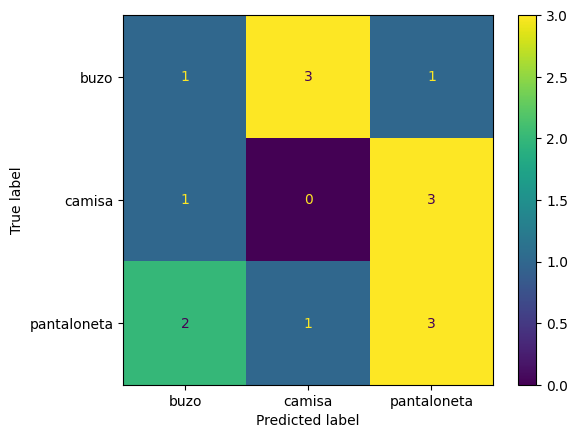

In [30]:
#9.2 Matriz de confusión

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

test_generator.reset()
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes
class_names = ['buzo', 'camisa', 'pantaloneta']

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.show()

La matriz de confusión evidencia dificultades para diferenciar clases visualmente similares.

# 9.3 Reporte de clasificación

In [31]:
#9.3 Reporte de clasificación

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        buzo       0.25      0.20      0.22         5
      camisa       0.00      0.00      0.00         4
 pantaloneta       0.43      0.50      0.46         6

    accuracy                           0.27        15
   macro avg       0.23      0.23      0.23        15
weighted avg       0.25      0.27      0.26        15



El reporte de clasificación muestra un mejor rendimiento en la clase pantaloneta y un desempeño moderado en las demás clases.

#10. Visualización del rendimiento del modelo

# Visualización de Resultados

Se presentan las gráficas de accuracy y loss para analizar el comportamiento del modelo durante el entrenamiento.

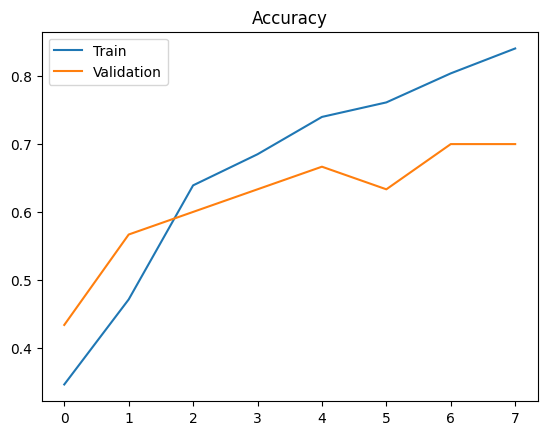

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

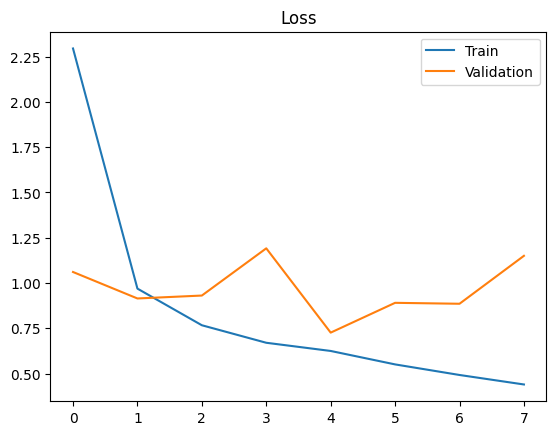

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')

plt.legend(['Train','Validation'])

plt.show()

#11. Probar imágenes nuevas
Se realizaran predicciones utilizando imágenes nuevas  descargadas desde github https://github.com/Hamerson-jhoel/img_prueba/tree/main
para evaluar la capacidad de generalización del modelo.


In [34]:
!git clone https://github.com/Hamerson-jhoel/img_prueba.git

fatal: destination path 'img_prueba' already exists and is not an empty directory.


In [35]:
import os

print(os.listdir("/content"))

['.config', 'clasificacion-1', 'img_prueba', 'mejor_modelo.keras', 'sample_data']


In [36]:
print(os.listdir("/content/img_prueba"))

['4camisa.jpeg', '6pantaloneta.jpeg', '1buzo.jpeg', '.git', '5pantaloneta.jpeg', '3camisa.jpeg', '2buzo.jpeg']


#12. Predicción sobre imágenes nuevas externas al dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


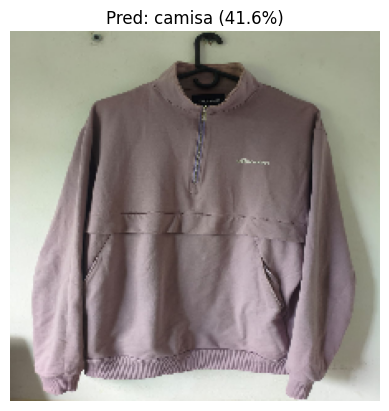

Imagen: /content/img_prueba/1buzo.jpeg
Predicción: camisa
Confianza: 41.58836 %
-----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


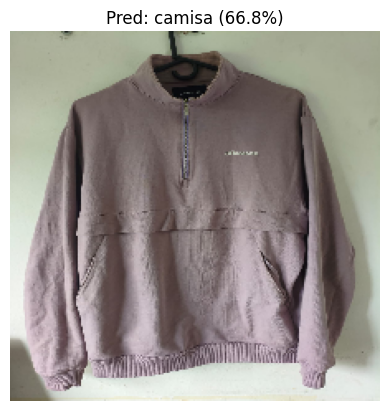

Imagen: /content/img_prueba/2buzo.jpeg
Predicción: camisa
Confianza: 66.76479 %
-----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


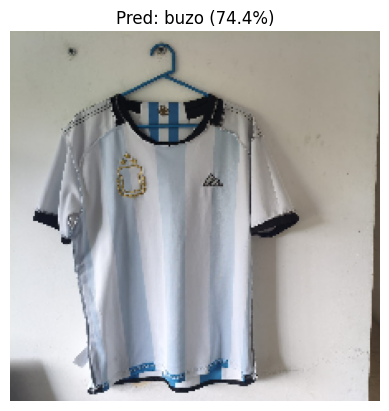

Imagen: /content/img_prueba/3camisa.jpeg
Predicción: buzo
Confianza: 74.37232 %
-----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


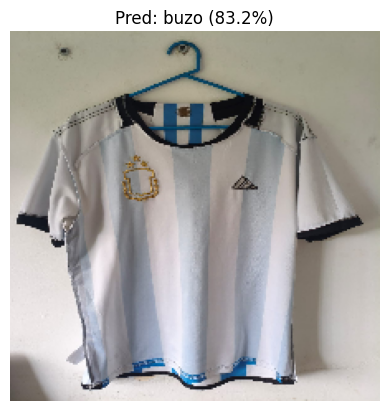

Imagen: /content/img_prueba/4camisa.jpeg
Predicción: buzo
Confianza: 83.19976 %
-----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


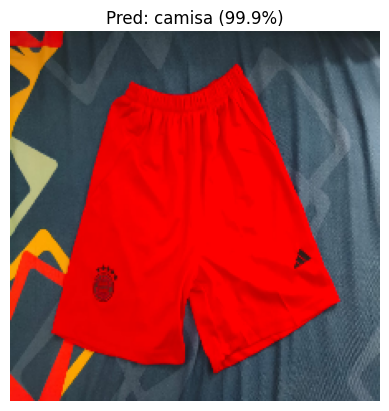

Imagen: /content/img_prueba/5pantaloneta.jpeg
Predicción: camisa
Confianza: 99.8665 %
-----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


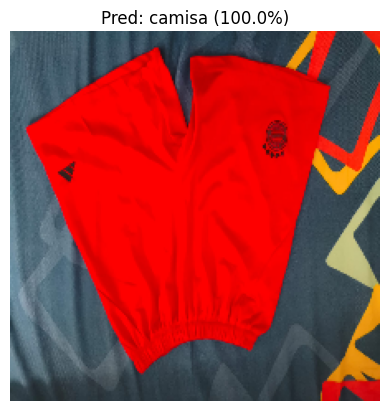

Imagen: /content/img_prueba/6pantaloneta.jpeg
Predicción: camisa
Confianza: 99.99669 %
-----------------------------------


In [37]:


from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Clases del modelo
class_names = ['buzo', 'camisa', 'pantaloneta']

# Lista de imágenes nuevas
imagenes_nuevas = [
    "/content/img_prueba/1buzo.jpeg",
    "/content/img_prueba/2buzo.jpeg",
    "/content/img_prueba/3camisa.jpeg",
    "/content/img_prueba/4camisa.jpeg",
    "/content/img_prueba/5pantaloneta.jpeg",
    "/content/img_prueba/6pantaloneta.jpeg"
]

# Recorrer imágenes
for img_path in imagenes_nuevas:

    # Cargar imagen
    img = image.load_img(img_path, target_size=(224,224))

    # Convertir imagen a arreglo
    img_array = image.img_to_array(img)/255.0

    # Agregar dimensión extra
    img_array = np.expand_dims(img_array, axis=0)

    # Realizar predicción
    prediction = model.predict(img_array)

    # Obtener clase predicha
    predicted_class = class_names[np.argmax(prediction)]

    # Obtener porcentaje de confianza
    confidence = np.max(prediction) * 100

    # Mostrar imagen con título (DESPUÉS de calcular predicción)
    plt.imshow(img)
    plt.title(f"Pred: {predicted_class} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

    # Mostrar resultados en texto
    print("Imagen:", img_path)
    print("Predicción:", predicted_class)
    print("Confianza:", confidence, "%")
    print("-----------------------------------")

#13. Predicciones sobre imágenes del conjunto de prueba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


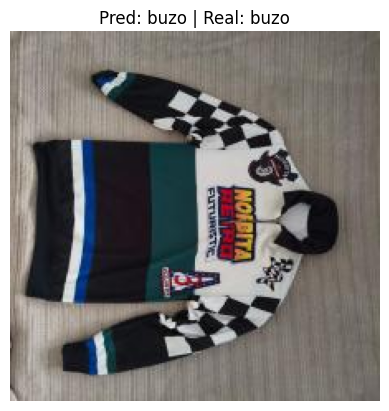

Clase real: buzo
Predicción: buzo
-----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


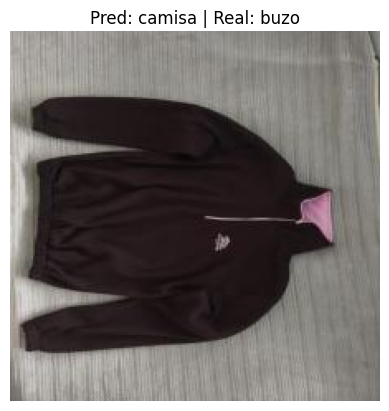

Clase real: buzo
Predicción: camisa
-----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


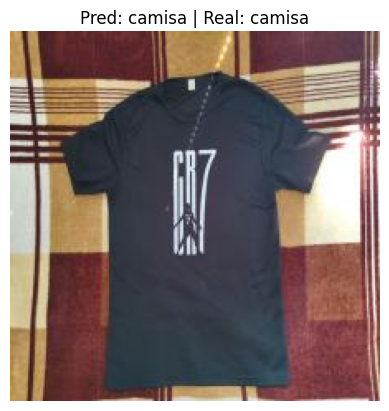

Clase real: camisa
Predicción: camisa
-----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


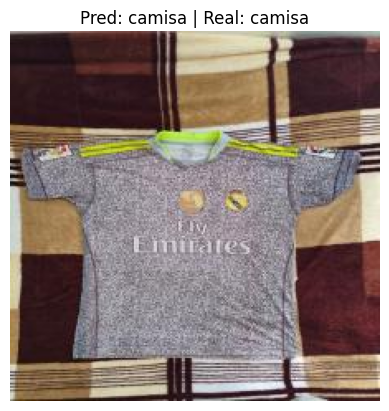

Clase real: camisa
Predicción: camisa
-----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


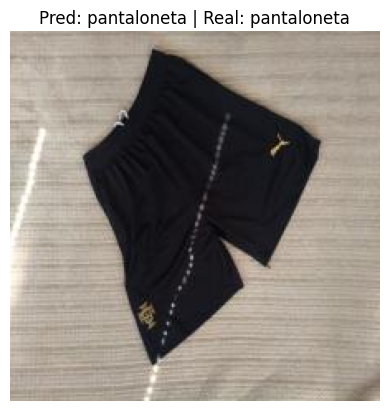

Clase real: pantaloneta
Predicción: pantaloneta
-----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


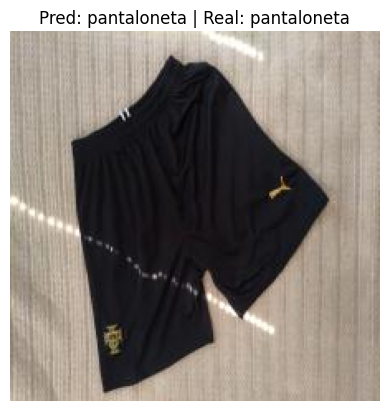

Clase real: pantaloneta
Predicción: pantaloneta
-----------------------------------


In [38]:


from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Clases del modelo
class_names = ['buzo', 'camisa', 'pantaloneta']

# Ruta del conjunto test
test_path = test_dir

# Lista para guardar imágenes seleccionadas
imagenes_test = []

# Seleccionar 2 imágenes aleatorias por cada clase
for clase in class_names:

    # Ruta de la carpeta de la clase
    carpeta = os.path.join(test_path, clase)

    # Obtener nombres de archivos
    archivos = os.listdir(carpeta)

    # Seleccionar 2 imágenes aleatorias
    seleccionadas = random.sample(archivos, 2)

    # Guardar rutas de imágenes
    for archivo in seleccionadas:

        ruta_imagen = os.path.join(carpeta, archivo)

        imagenes_test.append((ruta_imagen, clase))

# Realizar predicciones
for ruta_imagen, clase_real in imagenes_test:

    # Cargar imagen
    img = image.load_img(ruta_imagen, target_size=(224,224))

    # Convertir imagen a arreglo
    img_array = image.img_to_array(img)/255.0

    # Agregar dimensión extra
    img_array = np.expand_dims(img_array, axis=0)

    # Predicción del modelo
    prediction = model.predict(img_array)

    # Obtener clase predicha
    predicted_class = class_names[np.argmax(prediction)]

    # Mostrar imagen
    plt.imshow(img)
    plt.title(f"Pred: {predicted_class} | Real: {clase_real}")
    plt.axis('off')
    plt.show()
    # Mostrar resultados
    print("Clase real:", clase_real)
    print("Predicción:", predicted_class)
    print("-----------------------------------")

# Análisis Crítico

El modelo logró clasificar correctamente las imágenes pertenecientes al conjunto de prueba interno del dataset.

Sin embargo, al evaluar el modelo con imágenes completamente nuevas y externas al conjunto de entrenamiento, se observaron errores de clasificación, especialmente entre las clases de camisa, buzo y pantaloneta.

Las gráficas de accuracy y loss muestran que el modelo aprendió adecuadamente los patrones del conjunto de entrenamiento, alcanzando un accuracy elevado. No obstante, también se evidencia una diferencia entre el rendimiento de entrenamiento y validación, lo cual indica un leve overfitting.

Esto puede deberse principalmente a:
- tamaño reducido del dataset,
- poca variedad de fondos y posiciones,
- similitud visual entre algunas prendas.

El uso de data augmentation permitió incrementar artificialmente el tamaño del dataset, mejorando parcialmente la capacidad de generalización del modelo.

# Posibles Mejoras

- Incrementar la cantidad de imágenes por clase para mejorar la capacidad de aprendizaje del modelo.

- Incluir imágenes con diferentes fondos, posiciones, distancias e iluminaciones para aumentar la capacidad de generalización.

- Aplicar técnicas de transfer learning utilizando arquitecturas preentrenadas como MobileNet, ResNet o EfficientNet.

- Entrenar el modelo durante un mayor número de épocas ajustando parámetros para evitar overfitting.

- Implementar técnicas adicionales de data augmentation como zoom, desplazamiento y cambios de contraste.

- Utilizar conjuntos de datos más balanceados entre las diferentes clases.

# Conclusiones

Se logró implementar correctamente un sistema de clasificación de imágenes utilizando una Red Neuronal Convolucional (CNN) y un conjunto de datos propio creado en Roboflow.

El modelo fue capaz de aprender características relevantes de las prendas de vestir y obtuvo un buen desempeño sobre las imágenes pertenecientes al conjunto de prueba interno.

Sin embargo, al evaluar imágenes completamente nuevas, el modelo presentó algunas confusiones entre clases visualmente similares, evidenciando limitaciones en la capacidad de generalización debido al tamaño reducido y poca variedad del dataset.

Las gráficas de accuracy y loss permitieron analizar el comportamiento del entrenamiento, observándose un buen aprendizaje del conjunto de entrenamiento y un leve overfitting durante la validación.

Finalmente, este taller permitió comprender la importancia del preprocesamiento, aumento de datos y diseño de arquitecturas CNN en problemas de clasificación de imágenes.